# Модуль 5. Бустинг как градиентный спуск в пространстве функций

**Интерактивная версия:** `lessons/lesson_5/web/index.html`

Одна процедура — три функции потерь на данных с выбросами.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import matplotlib.pyplot as plt
from gbcourse import datasets, GBRegressor
from gbcourse.plotting import use_course_style, plot_data, plot_truth

use_course_style()

squared  : MAE до истинной функции 0.410
absolute : MAE до истинной функции 0.135
huber    : MAE до истинной функции 0.365


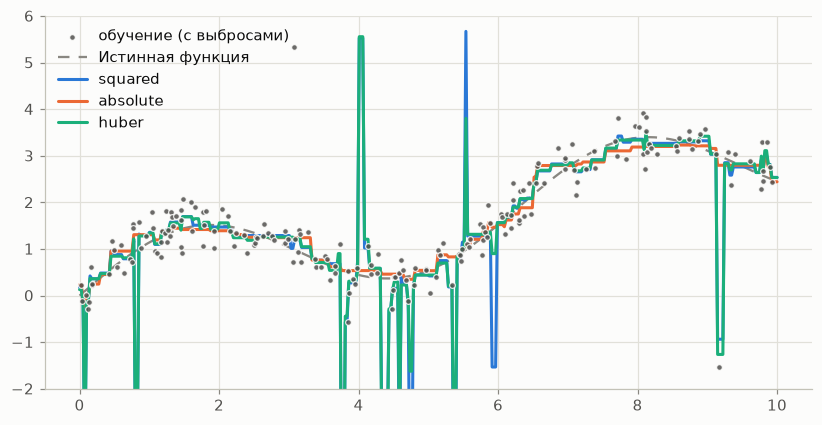

In [2]:
X, y = datasets.regression_1d(kind="wave", n=300, noise=0.3, seed=51, outliers=0.08)
X_tr, X_te, y_tr, y_te = datasets.train_test_split(X, y, test_size=0.3, seed=0)
grid = np.linspace(0, 10, 400).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(9, 4.4))
plot_data(ax, X_tr, y_tr, label="обучение (с выбросами)", s=14)
plot_truth(ax, "wave")
clean = datasets.true_function("wave", X_te[:, 0])
for loss in ("squared", "absolute", "huber"):
    m = GBRegressor(loss=loss, huber_delta=1.0, n_estimators=300, learning_rate=0.1, max_depth=2).fit(X_tr, y_tr)
    ax.plot(grid, m.predict(grid), lw=2, label=loss)
    print(f"{loss:9s}: MAE до истинной функции {np.mean(np.abs(clean - m.predict(X_te))):.3f}")
ax.set_ylim(-2, 6)
ax.legend()
plt.show()

Псевдо-остатки в первой итерации для каждой функции потерь:

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


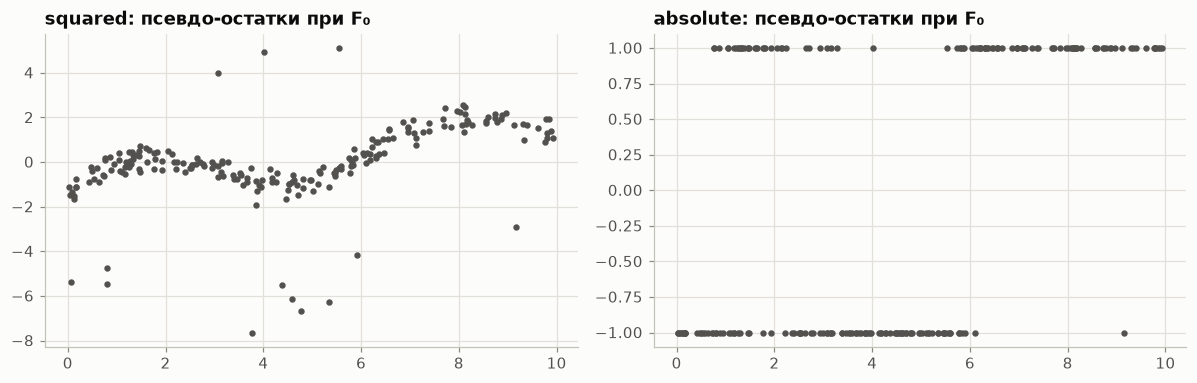

In [3]:
from gbcourse import get_loss

F0 = {"squared": y_tr.mean(), "absolute": np.median(y_tr)}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)
for ax, name in zip(axes, F0):
    r = get_loss(name).negative_gradient(y_tr, np.full_like(y_tr, F0[name]))
    ax.scatter(X_tr[:, 0], r, s=10, color="#52514e")
    ax.set_title(f"{name}: псевдо-остатки при F₀")
plt.tight_layout()
plt.show()

## Упражнения

1. Какая функция потерь даёт наименьшую MAE до истины при доле выбросов 0%? А при 20%?

Решения: `python lessons/lesson_5/exercises/solutions.py`.